Movie Review Sentiment Analysis System

In [1]:
import pandas as pd

data = {
    'review': [
        "The acting was brilliant and the story kept me engaged throughout.",
        "The movie was boring and the screenplay was weak.",
        "The film was average; some scenes were good while others were not."
    ],
    'sentiment': ['positive', 'negative', 'neutral']
}

df = pd.DataFrame(data)
print(df.head())

                                              review sentiment
0  The acting was brilliant and the story kept me...  positive
1  The movie was boring and the screenplay was weak.  negative
2  The film was average; some scenes were good wh...   neutral


Text preprocessing improves the quality of the data before training the model.

Steps:
Convert text to lowercase
Remove punctuation and special characters
Remove stop words
Tokenization
Stemming or lemmatization

In [3]:
import nltk
import re
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['clean_review'] = df['review'].apply(preprocess)

print(df[['review', 'clean_review']])

[nltk_data] Downloading package stopwords to /root/nltk_data...


                                              review  \
0  The acting was brilliant and the story kept me...   
1  The movie was boring and the screenplay was weak.   
2  The film was average; some scenes were good wh...   

                                     clean_review  
0  acting brilliant story kept engaged throughout  
1                    movie boring screenplay weak  
2                 film average scenes good others  


[nltk_data]   Unzipping corpora/stopwords.zip.


Machine learning techniques such as:

Naive Bayes
Logistic Regression
Support Vector Machine (SVM)
Deep Learning (LSTM, BERT)

Example using TF-IDF and Logistic Regression:

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = df['clean_review']
y = df['sentiment']

vectorizer = TfidfVectorizer()

X_tfidf = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00       0.0
    positive       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

he trained model can classify new reviews into:

Positive: Audience enjoyed acting, storyline, music, or entertainment value.
Negative: Audience expressed dissatisfaction with plot, direction, or performances.
Neutral: Mixed or balanced opinions without strong emotions.

In [5]:
new_review = ["The music was excellent, but the story was average."]

clean_text = preprocess(new_review[0])

vector = vectorizer.transform([clean_text])

result = model.predict(vector)

print("Predicted Sentiment:", result[0])

Predicted Sentiment: neutral


Sentiment Distribution Bar Chart

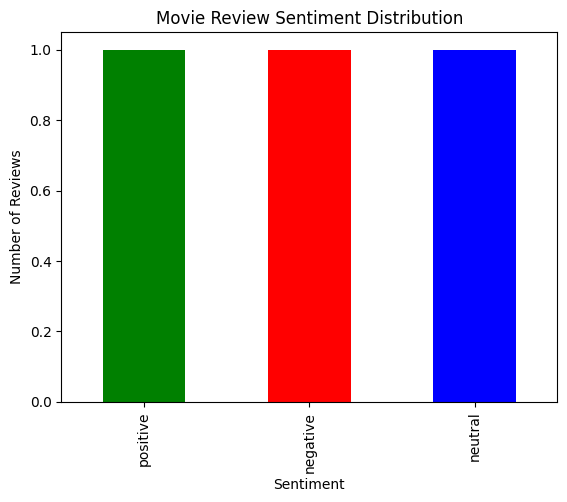

In [6]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentiment'].value_counts()

sentiment_counts.plot(
    kind='bar',
    color=['green', 'red', 'blue']
)

plt.title('Movie Review Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

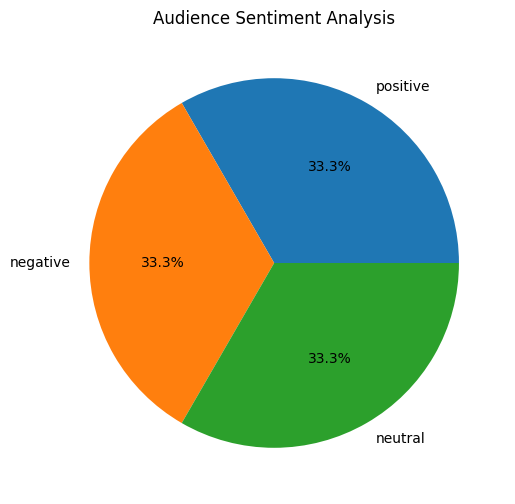

In [7]:
sentiment_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Audience Sentiment Analysis')
plt.ylabel('')
plt.show()


Word Cloud for Positive Reviews

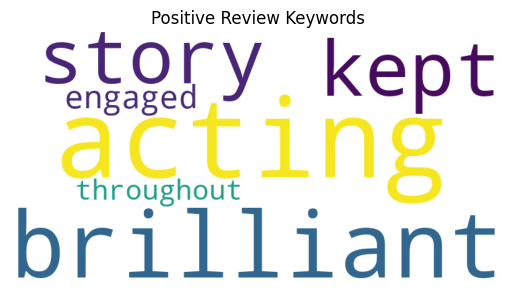

In [8]:
from wordcloud import WordCloud

positive_text = " ".join(
    df[df['sentiment'] == 'positive']['clean_review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title('Positive Review Keywords')
plt.show()